In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sb

In [145]:
df = pd.read_csv('tesla_stock_data.csv')
df["Date"] = pd.to_datetime(df["Date"])

df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2015-09-21,17.598667,18.104668,17.053333,17.613333,91803000,0.0,0.0
1,2015-09-22,17.268667,17.510000,17.058001,17.396000,54966000,0.0,0.0
2,2015-09-23,17.463333,17.472000,17.172001,17.403999,39012000,0.0,0.0
3,2015-09-24,17.302000,17.563334,17.080667,17.541332,51723000,0.0,0.0
4,2015-09-25,17.774000,17.794001,17.076668,17.127333,56601000,0.0,0.0
...,...,...,...,...,...,...,...,...
2510,2025-09-15,423.130005,425.700012,402.429993,410.040009,163823700,0.0,0.0
2511,2025-09-16,414.500000,423.250000,411.429993,421.619995,104285700,0.0,0.0
2512,2025-09-17,415.750000,428.309998,409.670013,425.859985,106133500,0.0,0.0
2513,2025-09-18,428.869995,432.220001,416.559998,416.850006,90454500,0.0,0.0


In [146]:
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [147]:
df.fillna(method="ffill", inplace=True) # Forward fill missing values

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26200\3782947524.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True) # Forward fill missing values


In [148]:
df['7-day MA'] = df['Close'].rolling(window=7).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change() # Percentage change


In [149]:
df['Daily Return']

0            NaN
1      -0.012339
2       0.000460
3       0.007891
4      -0.023601
          ...   
2510    0.035611
2511    0.028241
2512    0.010056
2513   -0.021157
2514    0.022118
Name: Daily Return, Length: 2515, dtype: float64

In [150]:
# Scaling Data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

In [151]:
print(scaled_data)

[[0.0170862 ]
 [0.01662407]
 [0.01664108]
 ...
 [0.88517527]
 [0.8660166 ]
 [0.88562186]]


In [152]:
from sklearn.model_selection import train_test_split

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

X, Y = create_dataset(scaled_data, look_back=240)
trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)

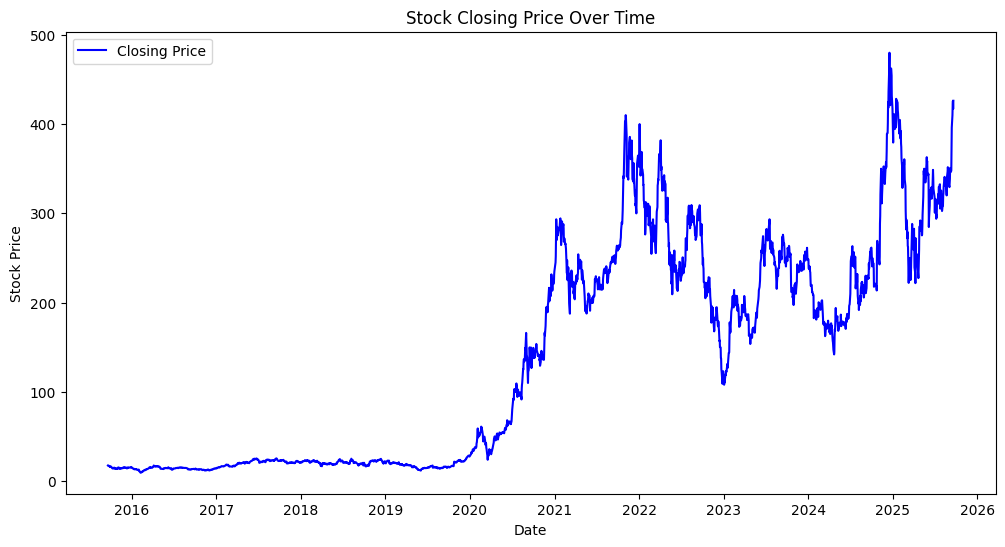

In [153]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Closing Price Over Time")
plt.legend()
plt.show()

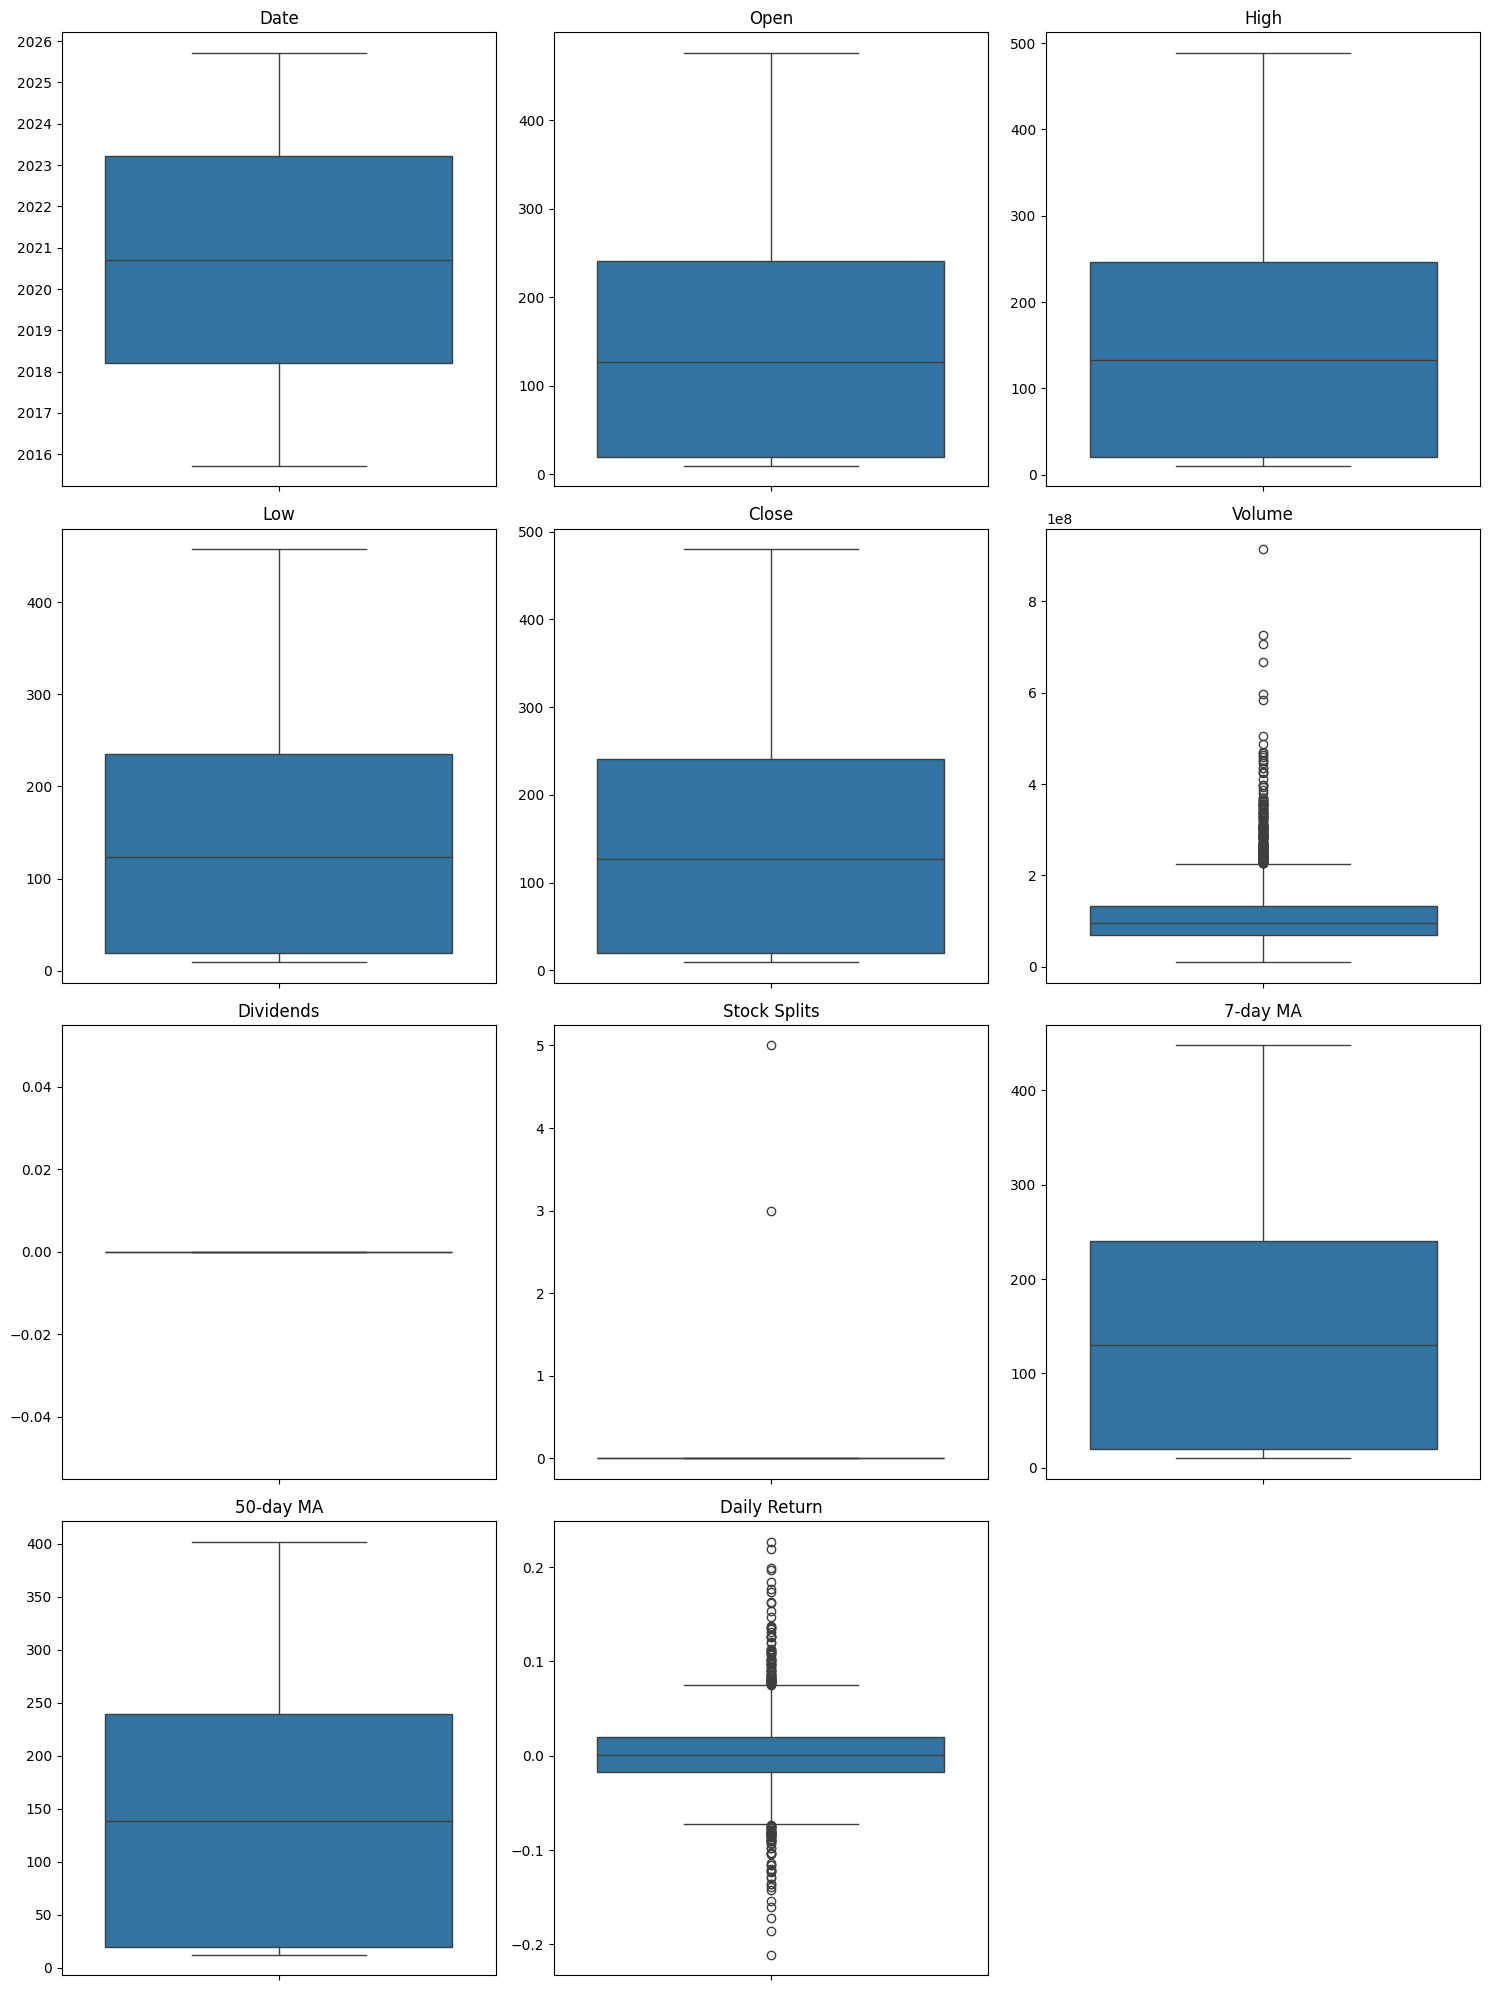

In [154]:
num_cols = 3
num_features = len(df.columns)
num_rows = math.ceil(num_features / num_cols)

fig = plt.figure(figsize=(15, num_rows * 5))

for i, x in enumerate(df.columns, start=1):
    plt.subplot(num_rows, num_cols, i)
    ax = sb.boxplot(df[x])
    ax.set(xlabel=None)
    plt.title(str(x), loc='center')
    plt.xlabel(None)
    plt.ylabel(None)
    
plt.tight_layout()
plt.show()

In [155]:
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [156]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    # LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)),
    # Dropout(0.2),
    LSTM(units=25, return_sequences=False),
    Dropout(0.1),
    # Dense(units=25),
    Dense(units=1)
])

In [157]:
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [158]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    trainX, trainY,
    epochs = 200,
    batch_size = 32,
    validation_split=0.1,
    shuffle=False,
    # callbacks=[early_stop]
)

Epoch 1/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0152 - val_loss: 0.0038
Epoch 2/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 0.0200 - val_loss: 0.0061
Epoch 3/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0064 - val_loss: 0.0010
Epoch 4/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 5/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 6/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0021 - val_loss: 9.4744e-04
Epoch 7/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0020 - val_loss: 9.4168e-04
Epoch 8/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 9/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 10/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0024 - val_loss: 8.8900e-04
Epoch 11/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 12/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 

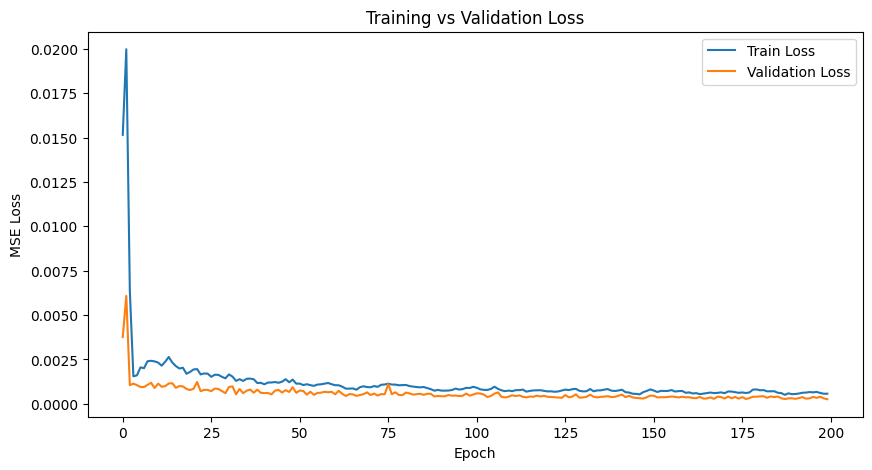

In [159]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [160]:
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [161]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 12.62000220323329


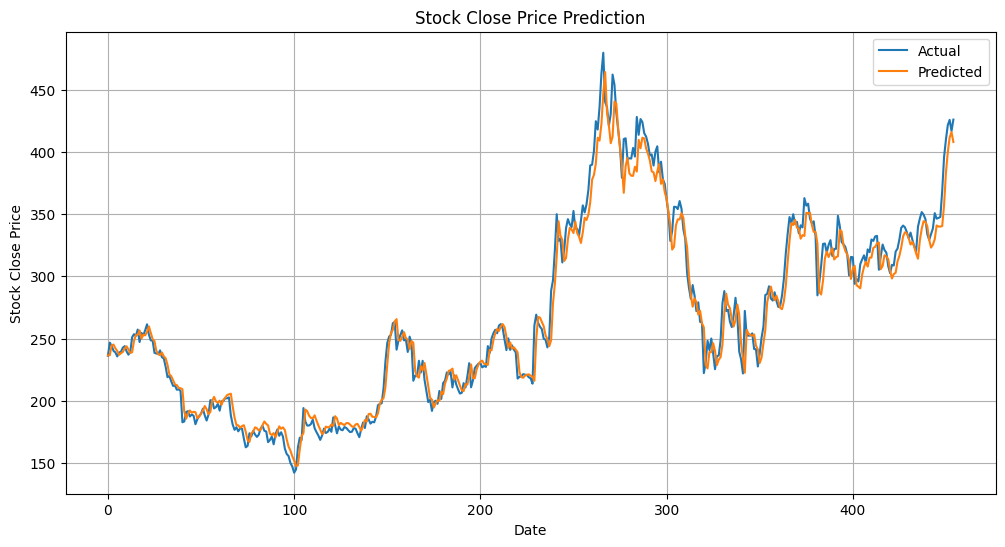

In [162]:
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Close Price")
plt.title("Stock Close Price Prediction")
plt.plot(testY, label="Actual")
plt.plot(testPredict, label="Predicted")
plt.grid(True)
plt.legend()
plt.show()

In [163]:
model.save("MediumModel.keras")

In [164]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  0
